# 1. Project Setup

In [1]:
from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
PROJECT_DIR = Path.cwd().parent

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"

EXTRACT_DIR = RAW_DIR / "extracted"
PET_IMAGES_DIR = EXTRACT_DIR / "PetImages"

MODEL_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

CAT_DIR = PET_IMAGES_DIR / "Cat"
DOG_DIR = PET_IMAGES_DIR / "Dog"

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")

Device: cpu


# 2. Dataset Validation

In [4]:
print(f"Cat directory exists: {CAT_DIR.exists()}")
print(f"Dog directory exists: {DOG_DIR.exists()}")

Cat directory exists: True
Dog directory exists: True


In [5]:
valid_extensions = {".jpg", ".jpeg", ".png"}

valid_files = []
invalid_files = []

for class_name in ["Cat", "Dog"]:
    class_dir = PET_IMAGES_DIR / class_name

    for file_path in sorted(class_dir.iterdir()):

        if file_path.suffix.lower() not in valid_extensions:
            invalid_files.append(
                (file_path, "Unsupported extension")
            )
            continue

        try:
            with Image.open(file_path) as img:
                img.verify()

            with Image.open(file_path) as img:
                img.load()

            valid_files.append(file_path)

        except Exception as e:
            invalid_files.append(
                (file_path, str(e))
            )

print(f"Valid images: {len(valid_files)}")
print(f"Invalid images: {len(invalid_files)}")

c:\Users\Elliot\anaconda3\envs\deep-learning\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Valid images: 24998
Invalid images: 4


In [6]:
for file_path, error in invalid_files:
    print(f"{file_path.name} -> {error}")

666.jpg -> cannot identify image file 'c:\\Users\\Elliot\\Desktop\\Cats vs Dogs\\data\\raw\\extracted\\PetImages\\Cat\\666.jpg'
Thumbs.db -> Unsupported extension
11702.jpg -> cannot identify image file 'c:\\Users\\Elliot\\Desktop\\Cats vs Dogs\\data\\raw\\extracted\\PetImages\\Dog\\11702.jpg'
Thumbs.db -> Unsupported extension


# 3. Dataset Preparation

In [7]:
image_records = []

for file_path in valid_files:

    if file_path.parent.name == "Cat":
        label = 0

    elif file_path.parent.name == "Dog":
        label = 1

    else:
        continue

    image_records.append({
        "path": str(file_path),
        "label": label
    })

df = pd.DataFrame(image_records)

print(f"Total images: {len(df)}")
print(df["label"].value_counts().sort_index())

Total images: 24998
label
0    12499
1    12499
Name: count, dtype: int64


In [8]:
class_counts = df["label"].map({
    0: "Cat",
    1: "Dog"
}).value_counts()

class_counts

label
Cat    12499
Dog    12499
Name: count, dtype: int64

# 4. Train / Validation / Test Split

In [9]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test: {len(test_df)}")

Train: 19998
Validation: 2500
Test: 2500


In [10]:
print("Train distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["label"].value_counts().sort_index())

print("\nTest distribution:")
print(test_df["label"].value_counts().sort_index())

Train distribution:
label
0    9999
1    9999
Name: count, dtype: int64

Validation distribution:
label
0    1250
1    1250
Name: count, dtype: int64

Test distribution:
label
0    1250
1    1250
Name: count, dtype: int64


# 5. Custom Dataset

In [11]:
class CatsDogsDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        image_path = self.dataframe.loc[idx, "path"]
        label = self.dataframe.loc[idx, "label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# 6. Data Augmentation & DataLoaders

In [12]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [14]:
train_dataset = CatsDogsDataset(
    train_df,
    transform=train_transform
)

val_dataset = CatsDogsDataset(
    val_df,
    transform=eval_transform
)

test_dataset = CatsDogsDataset(
    test_df,
    transform=eval_transform
)

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [16]:
images, labels = next(iter(train_loader))

print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Images shape: torch.Size([64, 3, 128, 128])
Labels shape: torch.Size([64])


# 7. CNN Baseline

In [17]:
class CNNBaseline(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),

            nn.Linear(128, 2)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [18]:
model = CNNBaseline().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

CNNBaseline(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


# 8. Training

In [19]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=10,
    patience=3,
    checkpoint_path=None
):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------

        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)

            train_correct += (
                predictions == labels
            ).sum().item()

            train_total += labels.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        # -------------------------
        # Validation
        # -------------------------

        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                val_correct += (
                    predictions == labels
                ).sum().item()

                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        # -------------------------
        # Checkpoint
        # -------------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            patience_counter = 0

            if checkpoint_path is not None:
                torch.save(
                    model.state_dict(),
                    checkpoint_path
                )

        else:

            patience_counter += 1

            if patience_counter >= patience:
                print("Early stopping.")
                break

    return model, history

Training note: The model was trained on the training set for 10 epochs. The best checkpoint was saved based on validation loss. The existing checkpoint is loaded below to avoid unnecessary retraining when reproducing the evaluation results.

In [ ]:
checkpoint_path = MODEL_DIR / "best_cnn_baseline.pth"

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=10,
    patience=3,
    checkpoint_path=checkpoint_path
)

# 9. Load Best Model

In [20]:
checkpoint_path = MODEL_DIR / "best_cnn_baseline.pth"

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best CNN checkpoint loaded.")

Best CNN checkpoint loaded.


# 10. Training Curves

In [21]:
if "history" in locals():

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["train_loss"],
        label="Train Loss"
    )

    plt.plot(
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()

In [22]:
if "history" in locals():

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["train_acc"],
        label="Train Accuracy"
    )

    plt.plot(
        history["val_acc"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.grid()
    plt.show()

# 11. Model Evaluation

In [38]:
model.eval()

test_loss = 0.0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= len(test_loader.dataset)
test_accuracy = accuracy_score(all_labels, all_preds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.3420
Test Accuracy: 0.8492


In [24]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Cat", "Dog"],
        digits=4
    )
)

              precision    recall  f1-score   support

         Cat     0.8908    0.7960    0.8407      1250
         Dog     0.8156    0.9024    0.8568      1250

    accuracy                         0.8492      2500
   macro avg     0.8532    0.8492    0.8488      2500
weighted avg     0.8532    0.8492    0.8488      2500



In [25]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm)

[[ 995  255]
 [ 122 1128]]


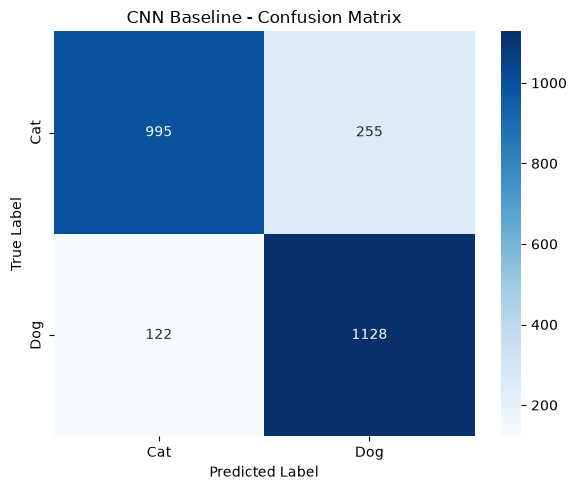

In [26]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Baseline - Confusion Matrix")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# 12. Error Analysis

In [27]:
model.eval()

wrong_images = []
wrong_labels = []
wrong_preds = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        wrong_mask = predictions != labels

        wrong_images.extend(
            images[wrong_mask].cpu()
        )

        wrong_labels.extend(
            labels[wrong_mask].cpu()
        )

        wrong_preds.extend(
            predictions[wrong_mask].cpu()
        )

print(
    f"Wrong predictions: {len(wrong_images)}"
)

Wrong predictions: 377


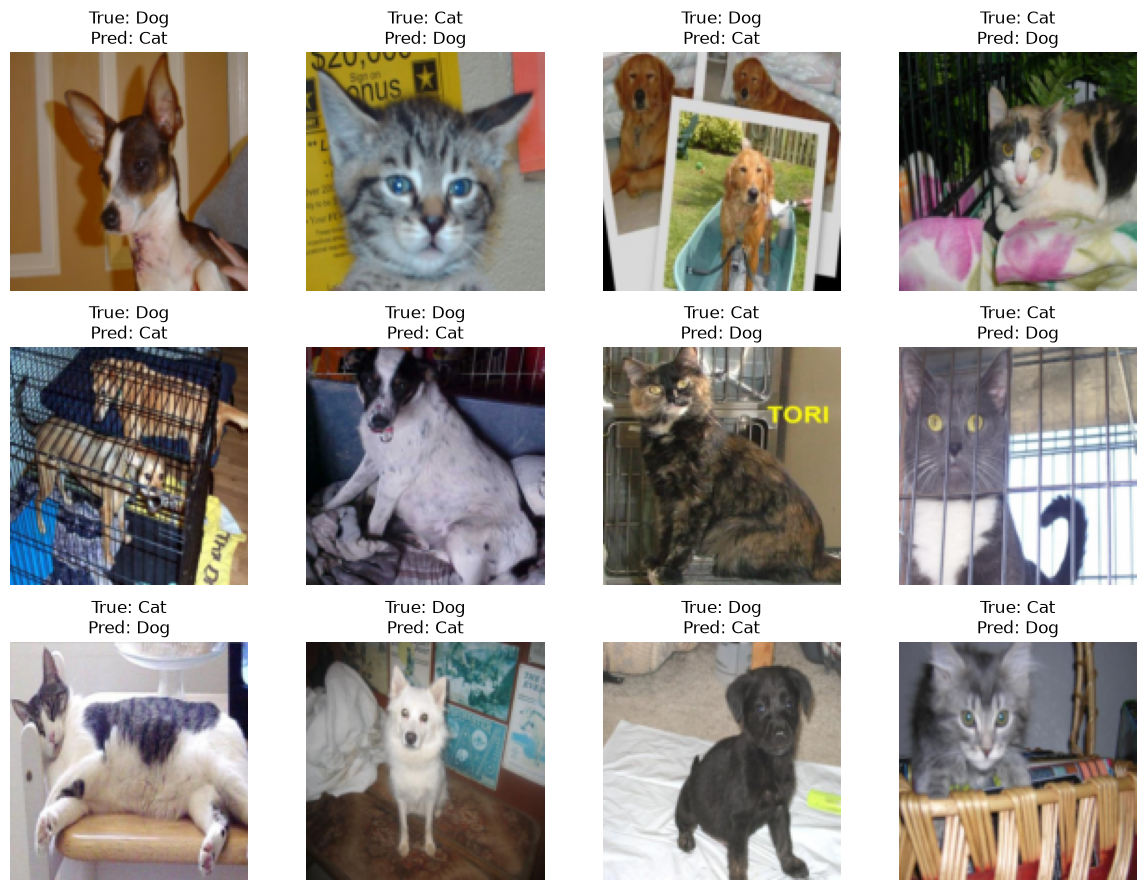

In [28]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(12, 9)
)

for i, ax in enumerate(axes.flat):

    image = wrong_images[i].permute(
        1, 2, 0
    )

    true_label = (
        "Cat"
        if wrong_labels[i] == 0
        else "Dog"
    )

    pred_label = (
        "Cat"
        if wrong_preds[i] == 0
        else "Dog"
    )

    ax.imshow(image)

    ax.set_title(
        f"True: {true_label}\n"
        f"Pred: {pred_label}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

### Error Analysis

The misclassified images were inspected to understand the main sources of error.

Common patterns included:

- Blurry or low-quality images
- Unusual poses or viewing angles
- Small subjects within the image
- Complex or cluttered backgrounds
- Visually ambiguous cat and dog images

These observations suggest that image quality, object scale, background complexity, and visual similarity between classes contribute to classification errors.

# 13. Transfer Learning

In [29]:
imagenet_mean = [
    0.485,
    0.456,
    0.406
]

imagenet_std = [
    0.229,
    0.224,
    0.225
]

train_transform_tl = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        imagenet_mean,
        imagenet_std
    )
])

eval_transform_tl = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(
        imagenet_mean,
        imagenet_std
    )
])

## Transfer Learning

MobileNetV3-Small pretrained on ImageNet was also investigated as a transfer learning approach.

Two strategies were explored:

1. Feature Extraction  
   The pretrained feature extractor was frozen and only the final classifier was trained.

2. Fine-Tuning  
   The final feature blocks were unfrozen and trained with a smaller learning rate.

The experiments showed that transfer learning did not outperform the custom CNN on this dataset and setup.

This suggests that pretrained features are not automatically superior when the target dataset differs substantially from the original pretraining domain.

### Why was the CNN retained as the final model?

The custom CNN provided stronger test performance in this project while remaining relatively simple and computationally manageable on CPU hardware.

Therefore, the CNN is used as the final model for inference and error analysis.

In [30]:
train_dataset_tl = CatsDogsDataset(
    train_df,
    transform=train_transform_tl
)

val_dataset_tl = CatsDogsDataset(
    val_df,
    transform=eval_transform_tl
)

test_dataset_tl = CatsDogsDataset(
    test_df,
    transform=eval_transform_tl
)

train_loader_tl = DataLoader(
    train_dataset_tl,
    batch_size=64,
    shuffle=True
)

val_loader_tl = DataLoader(
    val_dataset_tl,
    batch_size=64,
    shuffle=False
)

test_loader_tl = DataLoader(
    test_dataset_tl,
    batch_size=64,
    shuffle=False
)

# 14. MobileNet Feature Extraction

In [31]:
weights = models.MobileNet_V3_Small_Weights.DEFAULT

mobilenet = models.mobilenet_v3_small(
    weights=weights
)

for param in mobilenet.features.parameters():
    param.requires_grad = False

in_features = mobilenet.classifier[-1].in_features

mobilenet.classifier[-1] = nn.Linear(
    in_features,
    2
)

mobilenet = mobilenet.to(device)

In [32]:
criterion_tl = nn.CrossEntropyLoss()

optimizer_tl = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        mobilenet.parameters()
    ),
    lr=0.001
)

In [ ]:
mobilenet, history_tl = train_model(
    model=mobilenet,
    train_loader=train_loader_tl,
    val_loader=val_loader_tl,
    criterion=criterion_tl,
    optimizer=optimizer_tl,
    epochs=3,
    patience=2,
    checkpoint_path=MODEL_DIR / "mobilenet_feature_extraction.pth"
)

Feature extraction was explored during experimentation. The trained checkpoint was not retained, so its historical training result is documented in the project notes rather than re-evaluated from a fresh model.

# 15. Fine-Tuning

In [33]:
weights = models.MobileNet_V3_Small_Weights.DEFAULT

mobilenet_ft = models.mobilenet_v3_small(
    weights=weights
)

for param in mobilenet_ft.features.parameters():
    param.requires_grad = False

for param in mobilenet_ft.features[-3:].parameters():
    param.requires_grad = True

in_features = mobilenet_ft.classifier[-1].in_features

mobilenet_ft.classifier[-1] = nn.Linear(
    in_features,
    2
)

mobilenet_ft = mobilenet_ft.to(device)

In [34]:
criterion_ft = nn.CrossEntropyLoss()

optimizer_ft = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        mobilenet_ft.parameters()
    ),
    lr=0.0001
)

In [ ]:
mobilenet_ft, history_ft = train_model(
    model=mobilenet_ft,
    train_loader=train_loader_tl,
    val_loader=val_loader_tl,
    criterion=criterion_ft,
    optimizer=optimizer_ft,
    epochs=5,
    patience=2,
    checkpoint_path=MODEL_DIR / "mobilenet_finetuned.pth"
)

# 16. Single Image Prediction

In [35]:
def predict_image(image_path):

    image_path = Path(image_path)

    image = Image.open(
        image_path
    ).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor()
    ])

    image_tensor = transform(
        image
    ).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(
            image_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predicted_class = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = probabilities[
            0,
            predicted_class
        ].item()

    class_names = [
        "Cat",
        "Dog"
    ]

    print(
        f"Prediction: "
        f"{class_names[predicted_class]}"
    )

    print(
        f"Confidence: "
        f"{confidence:.2%}"
    )

In [ ]:
predict_image(
    PROJECT_DIR / "test_cat.jpg"
)

# 17. Final Results

In [36]:
results = pd.DataFrame({
    "Model": [
        "CNN Baseline",
        "MobileNetV3-Small Fine-Tuning"
    ],
    "Test Accuracy": [
        0.8492,
        0.8140
    ]
})

results

,Model,Test Accuracy
0,CNN Baseline,0.8492
1,MobileNetV3-Small Fine-Tuning,0.8140


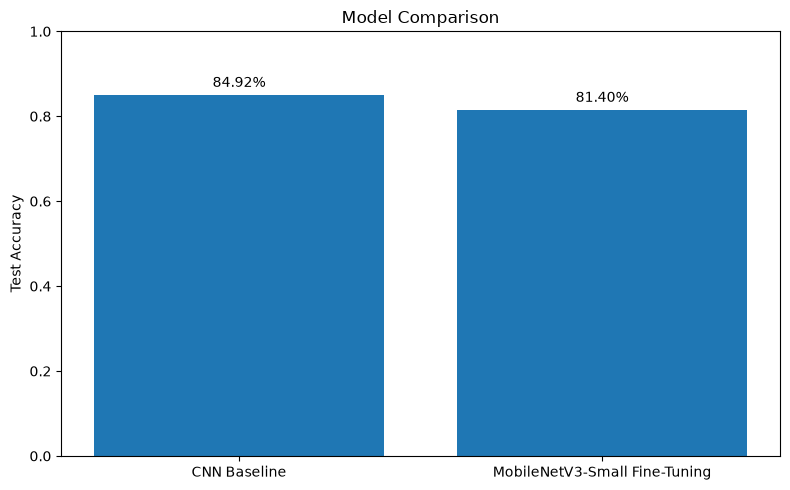

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Test Accuracy"]
)

plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.title("Model Comparison")

for i, value in enumerate(results["Test Accuracy"]):
    plt.text(i, value + 0.02, f"{value:.2%}", ha="center")

plt.tight_layout()
plt.show()

## Conclusion

This project demonstrated an end-to-end deep learning workflow for binary image classification using PyTorch.

The final CNN achieved a test accuracy of 84.92%.

The project covered:

- Real-world image dataset validation
- Custom PyTorch Dataset
- Data augmentation
- CNN architecture design
- Model training and checkpointing
- Test evaluation
- Classification report
- Confusion matrix
- Error analysis
- Transfer learning
- Fine-tuning
- Single-image inference

The error analysis showed that image quality, object scale, background complexity, and visually ambiguous examples were among the main challenges for the classifier.